In [1]:
import warnings, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, pointbiserialr
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
plt.rcParams['font.family'] = 'NanumGothic'   # 한글 렌더링

In [2]:
df = pd.read_csv('./data/air/train.csv')

print(f'행 {df.shape[0]:,} / 열 {df.shape[1]}')
print(f'중복 행: {df.duplicated().sum()}')

miss = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측비율(%)': (df.isnull().mean() * 100).round(3)
})
miss[miss['결측수'] > 0]

행 103,904 / 열 25
중복 행: 0


,결측수,결측비율(%)
Arrival Delay in Minutes,310,0.298


In [3]:
df.columns = [c.strip().replace(' ', '_').replace('/', '_') for c in df.columns]
print(list(df.columns))

['Unnamed:_0', 'id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction']


In [4]:
ID_COLS = ['Unnamed:_0', 'id']
before = df.shape[1]
df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
print(f'식별자 제거: {before} → {df.shape[1]}개 컬럼')

식별자 제거: 25 → 23개 컬럼


In [5]:
TARGET = 'satisfaction'
RS = 42
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RS, stratify=df[TARGET]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'train {train_df.shape}   test {test_df.shape}')
print(train_df[TARGET].value_counts(normalize=True).round(4).to_string())

train (83123, 23)   test (20781, 23)
satisfaction
neutral or dissatisfied    0.5667
satisfied                  0.4333


In [6]:
med = train_df['Arrival_Delay_in_Minutes'].median()
print(f'train 중앙값 {med}   (참고: train 평균 {train_df["Arrival_Delay_in_Minutes"].mean():.2f})')

for d in (train_df, test_df):
    d['Arrival_Delay_in_Minutes'] = d['Arrival_Delay_in_Minutes'].fillna(med)

print('결측치 잔여:', train_df.isnull().sum().sum(), test_df.isnull().sum().sum())

train 중앙값 0.0   (참고: train 평균 15.26)
결측치 잔여: 0 0


In [7]:
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
num_cols = train_df.select_dtypes(include='number').columns.tolist()

rating_cols = [c for c in num_cols if train_df[c].between(0, 5).all()]
other_num   = [c for c in num_cols if c not in rating_cols]

print(f'범주형 {len(cat_cols)}개 : {cat_cols}')
print(f'서비스 평점 {len(rating_cols)}개')
print(f'기타 수치형 {len(other_num)}개 : {other_num}')

card = pd.DataFrame({
    '고유값수': train_df[cat_cols + rating_cols].nunique(),
    '최빈값': train_df[cat_cols + rating_cols].mode().iloc[0]
})
display(card)

범주형 5개 : ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class', 'satisfaction']
서비스 평점 14개
기타 수치형 4개 : ['Age', 'Flight_Distance', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']


C:\Users\KDT11\AppData\Local\Temp\ipykernel_18796\3018374405.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include='object').columns.tolist()


,고유값수,최빈값
Gender,2,Female
Customer_Type,2,Loyal Customer
Type_of_Travel,2,Business travel
Class,3,Business
satisfaction,2,neutral or dissatisfied
Inflight_wifi_service,6,3
Departure_Arrival_time_convenient,6,4
Ease_of_Online_booking,6,3
Gate_location,6,3
Food_and_drink,6,4


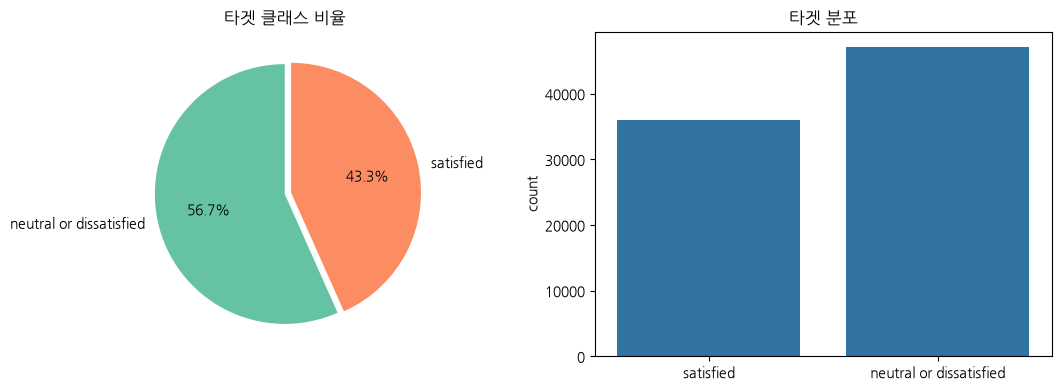

불균형비 1.31 : 1
→ 리샘플링 불필요


In [8]:
vc = train_df[TARGET].value_counts()
ratio = vc / vc.sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette('Set2'), explode=[0, 0.05])
ax[0].set_title('타겟 클래스 비율')
sns.countplot(data=train_df, x=TARGET, ax=ax[1])
ax[1].set_title('타겟 분포')
ax[1].set_xlabel('')
plt.tight_layout(); plt.show()

imb = ratio.max() / ratio.min()
print(f'불균형비 {imb:.2f} : 1')
print('→ 리샘플링 불필요' if imb < 1.5 else '→ 리샘플링 검토 필요')

In [9]:
sk = train_df[other_num].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
display(sk.to_frame('왜도').style.format('{:.3f}'))

high_skew = sk[sk.abs() > 0.5].index.tolist()
print(f'왜도 0.5 초과: {high_skew}')

,왜도
Departure_Delay_in_Minutes,6.806
Arrival_Delay_in_Minutes,6.669
Flight_Distance,1.114
Age,-0.003


왜도 0.5 초과: ['Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'Flight_Distance']


상관 0.5 초과 쌍


,,상관계수
Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,0.960
Inflight_wifi_service,Ease_of_Online_booking,0.717
Inflight_entertainment,Cleanliness,0.693
Seat_comfort,Cleanliness,0.679
Food_and_drink,Cleanliness,0.659
Baggage_handling,Inflight_service,0.626
Food_and_drink,Inflight_entertainment,0.624
Seat_comfort,Inflight_entertainment,0.610
Food_and_drink,Seat_comfort,0.576
On-board_service,Inflight_service,0.550


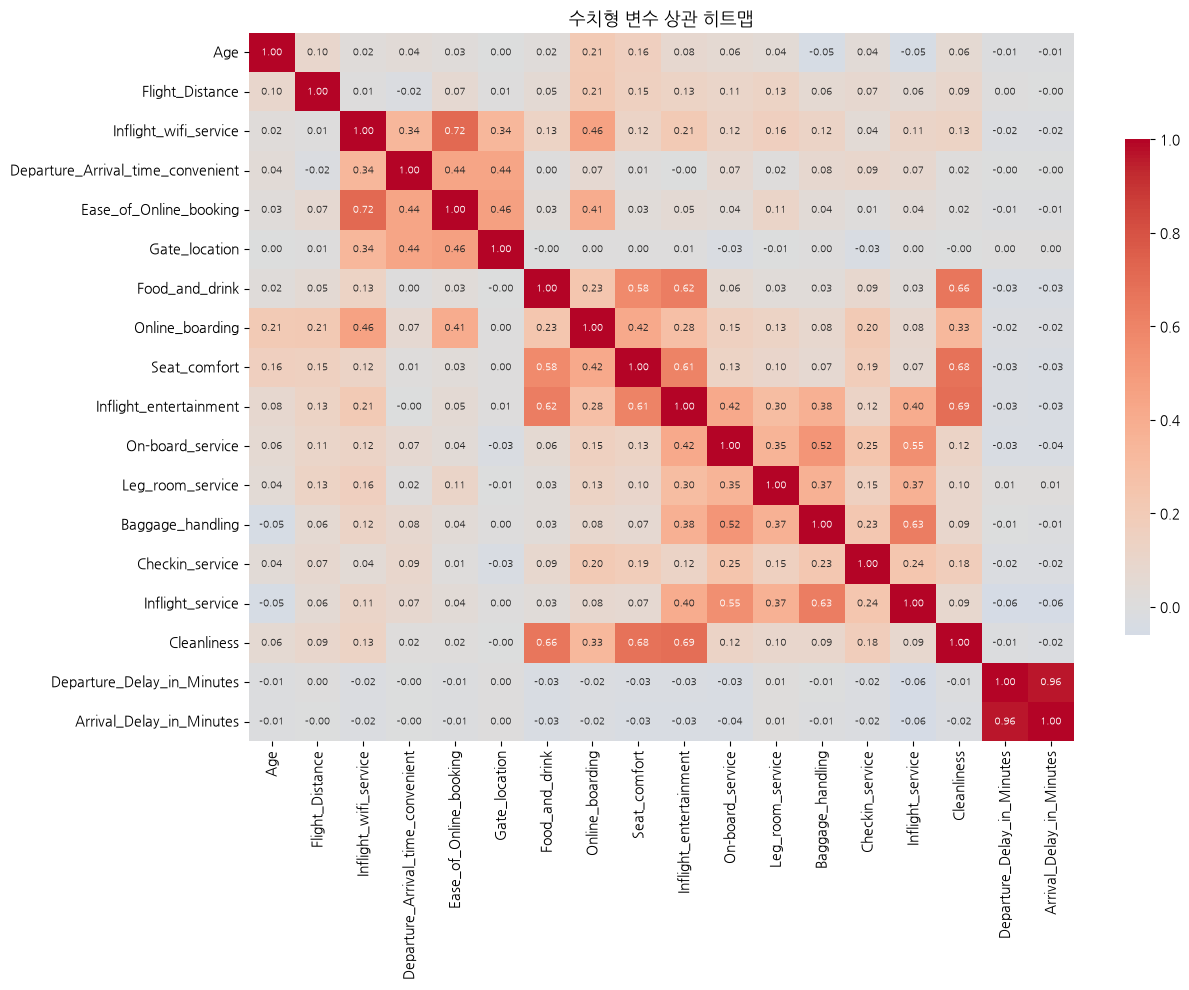

In [10]:
corr = train_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = corr.where(mask).stack().sort_values(ascending=False)

print('상관 0.5 초과 쌍')
display(pairs[pairs.abs() > 0.5].to_frame('상관계수').style.format('{:.3f}'))

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
plt.title('수치형 변수 상관 히트맵', fontsize=13)
plt.tight_layout(); plt.show()

타겟과의 point-biserial 상관 (상위/하위)


,r
Online_boarding,+0.5040
Inflight_entertainment,+0.3959
Seat_comfort,+0.3474
On-board_service,+0.3212
Leg_room_service,+0.3145
Cleanliness,+0.3033
Flight_Distance,+0.2967
Inflight_wifi_service,+0.2867
Baggage_handling,+0.2472
Inflight_service,+0.2446



도착 지연 구간별 만족률


,만족률,건수
Arrival_Delay_in_Minutes,,
0분,0.4724,"46,677"
1-5분,0.4819,"7,887"
6-15분,0.3598,"9,638"
16-30분,0.3514,"7,174"
31-60분,0.3545,"5,881"
61-120분,0.3502,"3,741"
120분+,0.3704,"2,125"


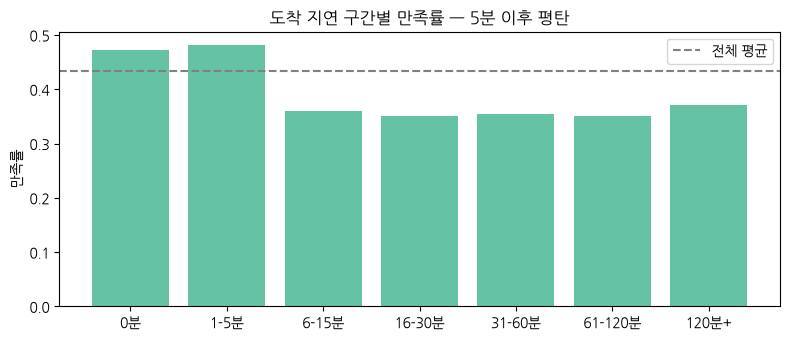

In [11]:
y_tr_bin = (train_df[TARGET] == 'satisfied').astype(int)

print('타겟과의 point-biserial 상관 (상위/하위)')
rs = {}
for c in num_cols:
    r, p = pointbiserialr(y_tr_bin, train_df[c])
    rs[c] = r
rs = pd.Series(rs).sort_values(key=abs, ascending=False)
display(rs.to_frame('r').style.format('{:+.4f}'))

bins = [-1, 0, 5, 15, 30, 60, 120, np.inf]
lbl  = ['0분', '1-5분', '6-15분', '16-30분', '31-60분', '61-120분', '120분+']
g = pd.cut(train_df['Arrival_Delay_in_Minutes'], bins=bins, labels=lbl)
tbl = pd.DataFrame({
    '만족률': y_tr_bin.groupby(g, observed=False).mean(),
    '건수': y_tr_bin.groupby(g, observed=False).size()
})
print('\n도착 지연 구간별 만족률')
display(tbl.style.format({'만족률': '{:.4f}', '건수': '{:,}'}))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(tbl.index, tbl['만족률'], color=sns.color_palette('Set2')[0])
ax.axhline(y_tr_bin.mean(), ls='--', c='gray', label='전체 평균')
ax.set_ylabel('만족률'); ax.set_title('도착 지연 구간별 만족률 — 5분 이후 평탄')
ax.legend(); plt.tight_layout(); plt.show()

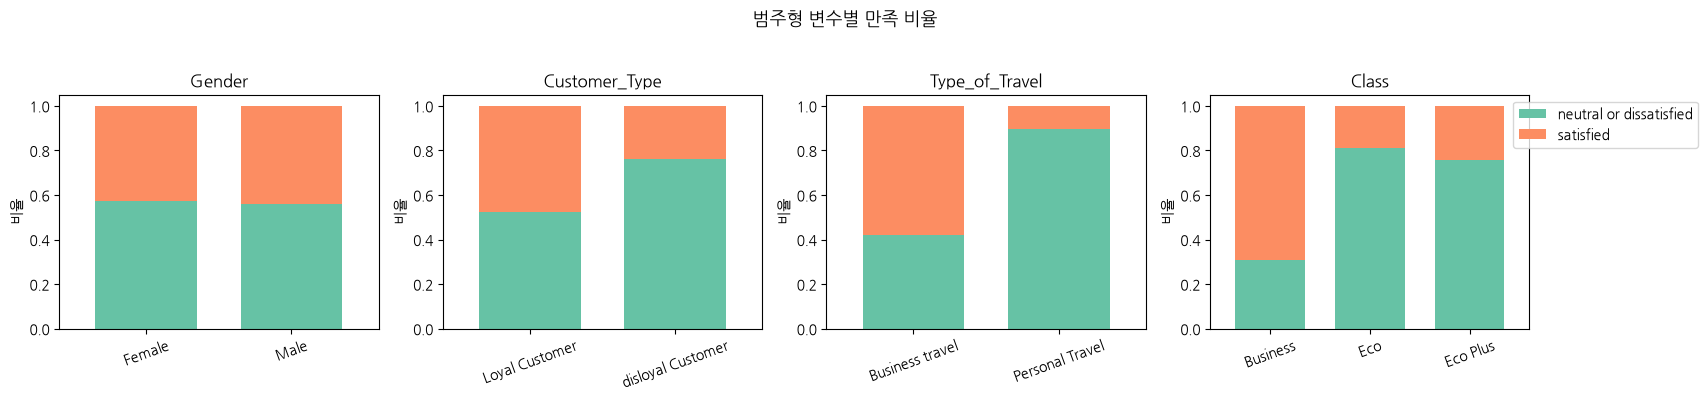

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, col in zip(axes, ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class']):
    ct = pd.crosstab(train_df[col], train_df[TARGET], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, legend=False, width=0.7,
            color=sns.color_palette('Set2')[:2])
    ax.set_title(col); ax.set_xlabel(''); ax.set_ylabel('비율')
    ax.tick_params(axis='x', rotation=20)
axes[-1].legend(title='', loc='upper right', bbox_to_anchor=(1.55, 1))
plt.suptitle('범주형 변수별 만족 비율', y=1.04, fontsize=13)
plt.tight_layout(); plt.show()

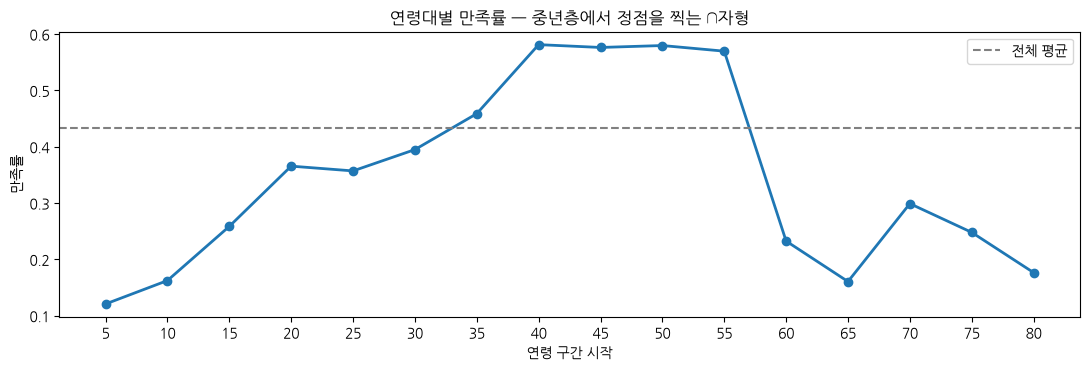

Age의 선형 상관계수: +0.1370  ← ∩자형이라 낮게 측정됨


In [13]:
# 연령 — 선형 상관으로는 잡히지 않는 ∩자형 패턴
age_bin = pd.cut(train_df['Age'], bins=range(0, 90, 5))
age_rate = y_tr_bin.groupby(age_bin, observed=False).mean()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot([str(i.left) for i in age_rate.index], age_rate.values, marker='o', lw=2)
ax.axhline(y_tr_bin.mean(), ls='--', c='gray', label='전체 평균')
ax.set_xlabel('연령 구간 시작'); ax.set_ylabel('만족률')
ax.set_title('연령대별 만족률 — 중년층에서 정점을 찍는 ∩자형')
ax.legend(); plt.tight_layout(); plt.show()

r_age, _ = pointbiserialr(y_tr_bin, train_df['Age'])
print(f'Age의 선형 상관계수: {r_age:+.4f}  ← ∩자형이라 낮게 측정됨')

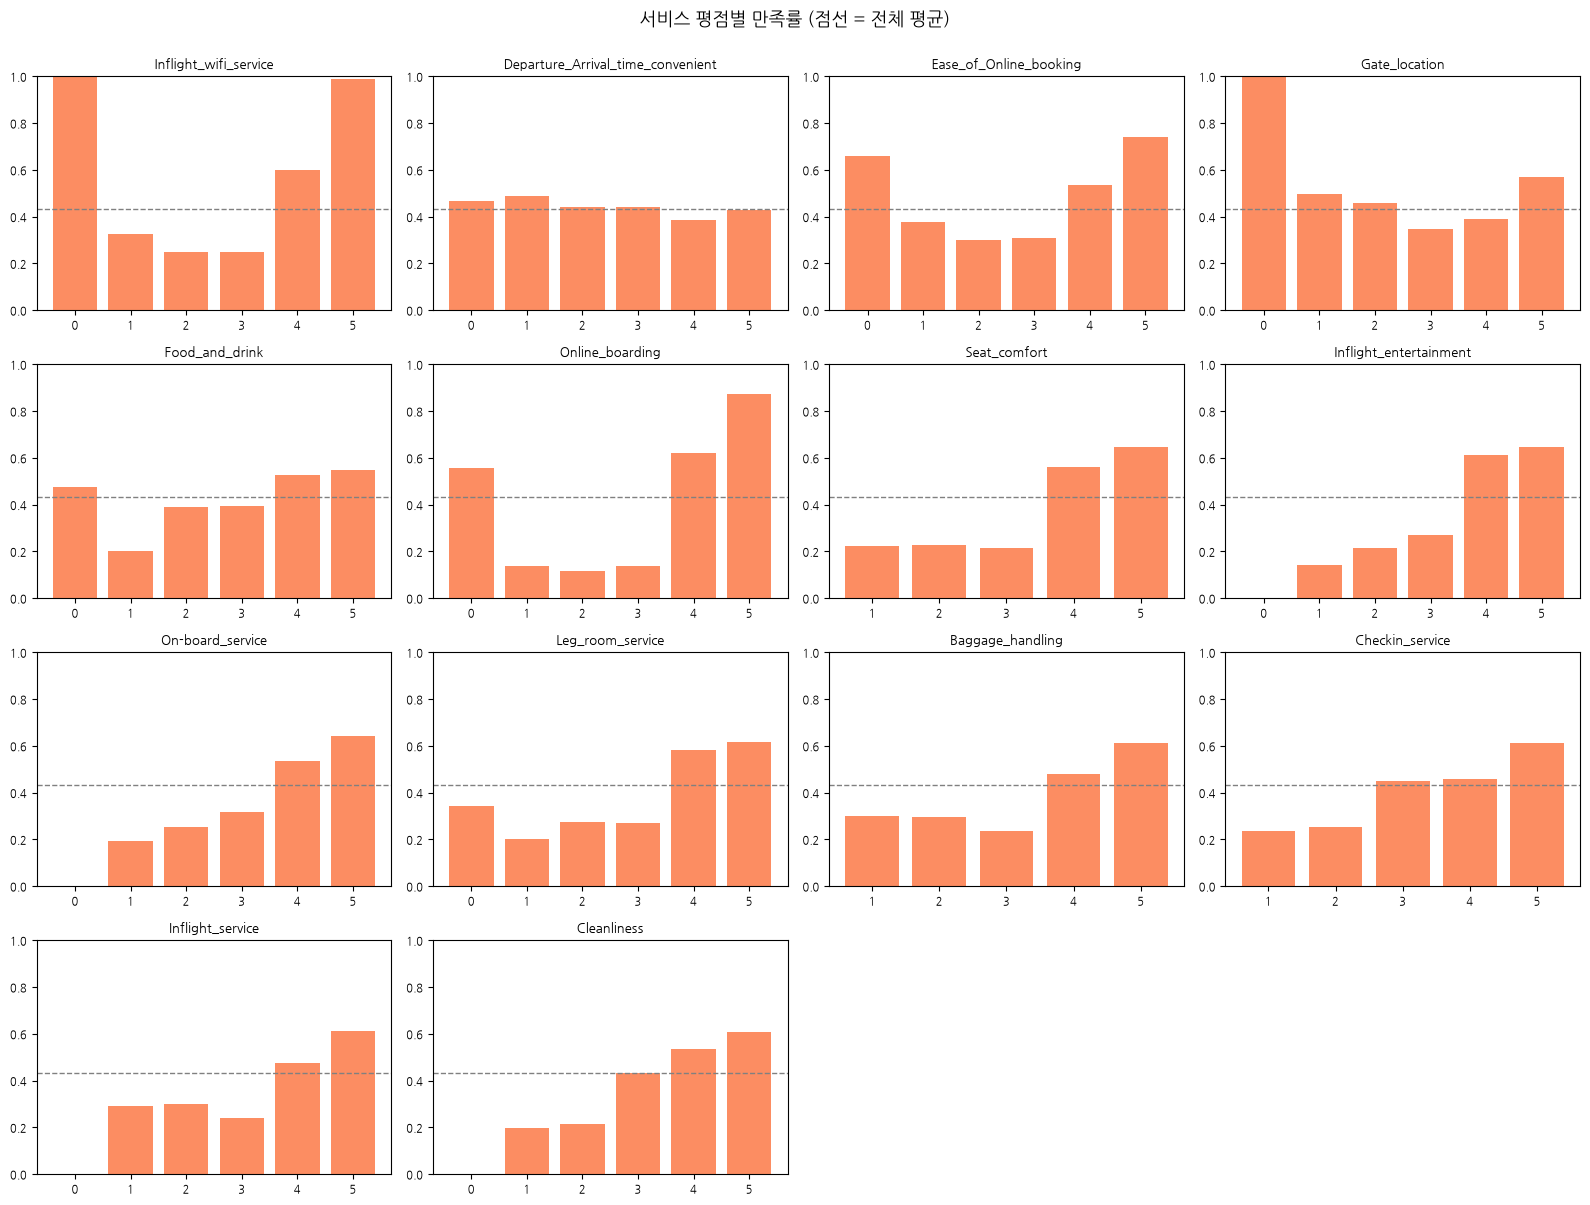

In [14]:
# 서비스 평점별 만족률 (groupby 활용)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), rating_cols):
    rate = y_tr_bin.groupby(train_df[col]).mean()
    ax.bar(rate.index.astype(str), rate.values, color=sns.color_palette('Set2')[1])
    ax.axhline(y_tr_bin.mean(), ls='--', c='gray', lw=1)
    ax.set_title(col, fontsize=9); ax.set_ylim(0, 1); ax.tick_params(labelsize=8)
for ax in axes.ravel()[len(rating_cols):]:
    ax.axis('off')
plt.suptitle('서비스 평점별 만족률 (점선 = 전체 평균)', y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

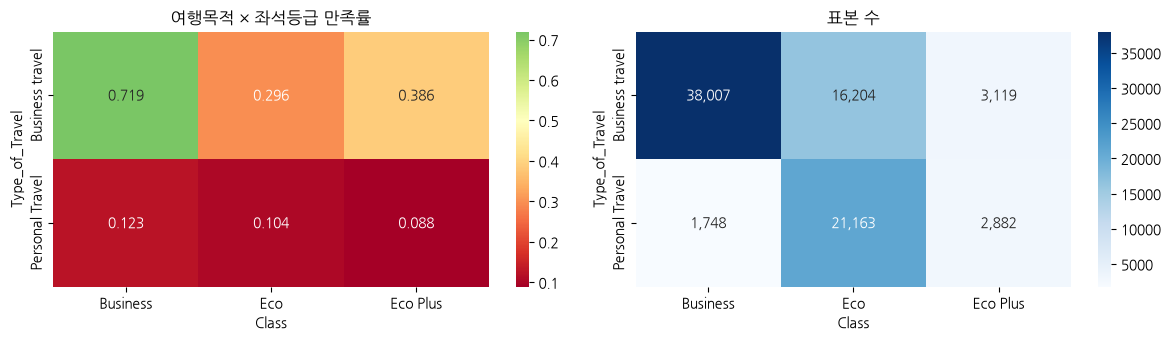

In [15]:
# 여행목적 × 좌석등급 교차 만족률
pivot = train_df.assign(sat=y_tr_bin).pivot_table(
    index='Type_of_Travel', columns='Class', values='sat', aggfunc='mean')
cnt = train_df.pivot_table(index='Type_of_Travel', columns='Class',
                           values='Age', aggfunc='size')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5, ax=ax[0])
ax[0].set_title('여행목적 × 좌석등급 만족률')
sns.heatmap(cnt, annot=True, fmt=',d', cmap='Blues', ax=ax[1])
ax[1].set_title('표본 수')
plt.tight_layout(); plt.show()

In [16]:
MAPS = {
    'Gender':         {'Male': 0, 'Female': 1},
    'Customer_Type':  {'Loyal Customer': 0, 'disloyal Customer': 1},
    'Type_of_Travel': {'Personal Travel': 0, 'Business travel': 1},
    'Class':          {'Eco': 0, 'Eco Plus': 1, 'Business': 2},   # 순서형
    TARGET:           {'neutral or dissatisfied': 0, 'satisfied': 1},
}

for c, m in MAPS.items():
    for d in (train_df, test_df):
        d[c] = d[c].map(m)
    assert train_df[c].notna().all() and test_df[c].notna().all(), f'{c} 매핑 실패'

print('인코딩 완료')
display(train_df.head(3))

인코딩 완료


,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure_Arrival_time_convenient,Ease_of_Online_booking,Gate_location,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,1,0,47,1,2,1521,3,3,3,3,...,4,4,4,4,4,4,3,0,0.0,1
1,0,1,35,1,2,2586,3,3,3,4,...,3,5,5,5,5,4,3,0,0.0,0
2,1,0,66,0,0,550,2,4,2,2,...,4,4,2,4,3,4,5,78,82.0,0


In [17]:
train_df = train_df.drop(columns=['Arrival_Delay_in_Minutes'])
test_df = test_df.drop(columns=['Arrival_Delay_in_Minutes'])
X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET].to_numpy()
X_test  = test_df.drop(columns=TARGET)
y_test  = test_df[TARGET].to_numpy()

assert TARGET not in X_train.columns, '타겟이 피처에 섞였습니다'
assert X_train.shape[1] == train_df.shape[1] - 1
assert list(X_train.columns) == list(X_test.columns), 'train/test 컬럼 불일치'

FEATURES = X_train.columns.tolist()
print(f'피처 {len(FEATURES)}개')
print(FEATURES)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit은 train에만
X_test_s  = scaler.transform(X_test)        # test는 transform만

# 분포 sanity check — 로그 변환 누락 같은 실수를 잡아냄
chk = pd.DataFrame({
    'train_min': X_train_s.min(0), 'train_max': X_train_s.max(0),
    'test_min':  X_test_s.min(0),  'test_max':  X_test_s.max(0),
}, index=FEATURES)
display(chk.style.format('{:.2f}'))

피처 21개
['Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes']


,train_min,train_max,test_min,test_max
Gender,-1.01,0.99,-1.01,0.99
Customer_Type,-0.47,2.11,-0.47,2.11
Age,-2.14,3.01,-2.14,2.68
Type_of_Travel,-1.49,0.67,-1.49,0.67
Class,-1.07,1.01,-1.07,1.01
Flight_Distance,-1.16,3.81,-1.16,3.81
Inflight_wifi_service,-2.06,1.71,-2.06,1.71
Departure_Arrival_time_convenient,-2.00,1.27,-2.00,1.27
Ease_of_Online_booking,-1.97,1.60,-1.97,1.60
Gate_location,-2.33,1.58,-1.55,1.58


In [18]:
def chi2_rank(Xin):
    s = SelectKBest(chi2, k='all').fit(Xin, y_train)
    return pd.Series(s.scores_, index=FEATURES).sort_values(ascending=False).head(8)

raw_rank = chi2_rank(X_train)
mm_rank  = chi2_rank(MinMaxScaler().fit_transform(X_train))

cmp_df = pd.DataFrame({
    '원본_변수': raw_rank.index,   '원본_chi2': raw_rank.values.round(1),
    'MinMax_변수': mm_rank.index, 'MinMax_chi2': mm_rank.values.round(1),
})
print('chi2 상위 8개 — 스케일링 전후로 순위가 뒤집힘')
display(cmp_df)

chi2 상위 8개 — 스케일링 전후로 순위가 뒤집힘


,원본_변수,원본_chi2,MinMax_변수,MinMax_chi2
0,Flight_Distance,6108666.1,Class,9078.0
1,Departure_Delay_in_Minutes,19778.5,Type_of_Travel,5138.2
2,Class,18156.0,Customer_Type,2403.8
3,Online_boarding,11823.9,Online_boarding,2364.8
4,Age,9063.9,Seat_comfort,1792.5
5,Inflight_entertainment,6893.3,Inflight_entertainment,1378.7
6,Type_of_Travel,5138.2,Flight_Distance,1266.7
7,Seat_comfort,5083.5,Inflight_wifi_service,881.0


In [19]:
def run_model(name, model, X_tr, y_tr, X_te, y_te, verbose=True):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    took = time.time() - t0

    sub = np.random.RandomState(RS).choice(len(X_tr), 15000, replace=False)
    p_tr, p_te = model.predict(X_tr[sub]), model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    acc_tr = accuracy_score(y_tr[sub], p_tr)   # 15k 샘플 기준
    acc_te = accuracy_score(y_te, p_te)
    auc    = roc_auc_score(y_te, proba)
    rep    = classification_report(y_te, p_te, output_dict=True)
    gap    = acc_tr - acc_te
    flag   = '과적합 의심' if gap > 0.05 else '정상'

    if verbose:
        print(f'{name:22s} train {acc_tr:.4f} | test {acc_te:.4f} | '
              f'AUC {auc:.4f} | F1 {rep["1"]["f1-score"]:.4f} | '
              f'격차 {gap:+.4f} ({flag}) | {took:.1f}s')

    return dict(모델=name, train정확도=acc_tr, test정확도=acc_te, ROC_AUC=auc,
                F1_만족=rep['1']['f1-score'], precision_만족=rep['1']['precision'],
                recall_만족=rep['1']['recall'], 격차=gap, 판정=flag,
                시간초=took, _model=model, _proba=proba, _pred=p_te)


MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RS),
    'KNN (k=5)':          KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'DecisionTree(d=12)': DecisionTreeClassifier(max_depth=12, random_state=RS),
    'RandomForest':       RandomForestClassifier(n_estimators=150, random_state=RS, n_jobs=-1),
    'ExtraTrees':         ExtraTreesClassifier(n_estimators=150, random_state=RS, n_jobs=-1),
    'XGBoost':            XGBClassifier(n_estimators=300, eval_metric='logloss',
                                        random_state=RS, n_jobs=-1),
    'LightGBM':           LGBMClassifier(n_estimators=300, random_state=RS,
                                         n_jobs=-1, verbose=-1),
}

results = []
for name, m in MODELS.items():
    results.append(run_model(name, m, X_train_s, y_train, X_test_s, y_test))

LogisticRegression     train 0.8727 | test 0.8767 | AUC 0.9278 | F1 0.8555 | 격차 -0.0040 (정상) | 0.1s
KNN (k=5)              train 0.9478 | test 0.9296 | AUC 0.9706 | F1 0.9161 | 격차 +0.0182 (정상) | 0.0s
DecisionTree(d=12)     train 0.9624 | test 0.9540 | AUC 0.9846 | F1 0.9463 | 격차 +0.0084 (정상) | 0.3s
RandomForest           train 1.0000 | test 0.9630 | AUC 0.9942 | F1 0.9568 | 격차 +0.0370 (정상) | 1.5s
ExtraTrees             train 1.0000 | test 0.9608 | AUC 0.9933 | F1 0.9542 | 격차 +0.0392 (정상) | 1.2s
XGBoost                train 0.9949 | test 0.9631 | AUC 0.9950 | F1 0.9571 | 격차 +0.0317 (정상) | 1.0s
LightGBM               train 0.9779 | test 0.9663 | AUC 0.9956 | F1 0.9606 | 격차 +0.0117 (정상) | 1.3s


,모델,train정확도,test정확도,ROC_AUC,F1_만족,precision_만족,recall_만족,격차,판정,시간초
0,LightGBM,0.9779,0.9663,0.9956,0.9606,0.9735,0.9479,+0.0117,정상,1.3
1,XGBoost,0.9949,0.9631,0.9950,0.9571,0.9649,0.9495,+0.0317,정상,1.0
2,RandomForest,1.0000,0.9630,0.9942,0.9568,0.9689,0.9450,+0.0370,정상,1.5
3,ExtraTrees,1.0000,0.9608,0.9933,0.9542,0.9665,0.9421,+0.0392,정상,1.2
4,DecisionTree(d=12),0.9624,0.9540,0.9846,0.9463,0.9588,0.9340,+0.0084,정상,0.3
5,KNN (k=5),0.9478,0.9296,0.9706,0.9161,0.9468,0.8873,+0.0182,정상,0.0
6,LogisticRegression,0.8727,0.8767,0.9278,0.8555,0.8688,0.8426,-0.0040,정상,0.1


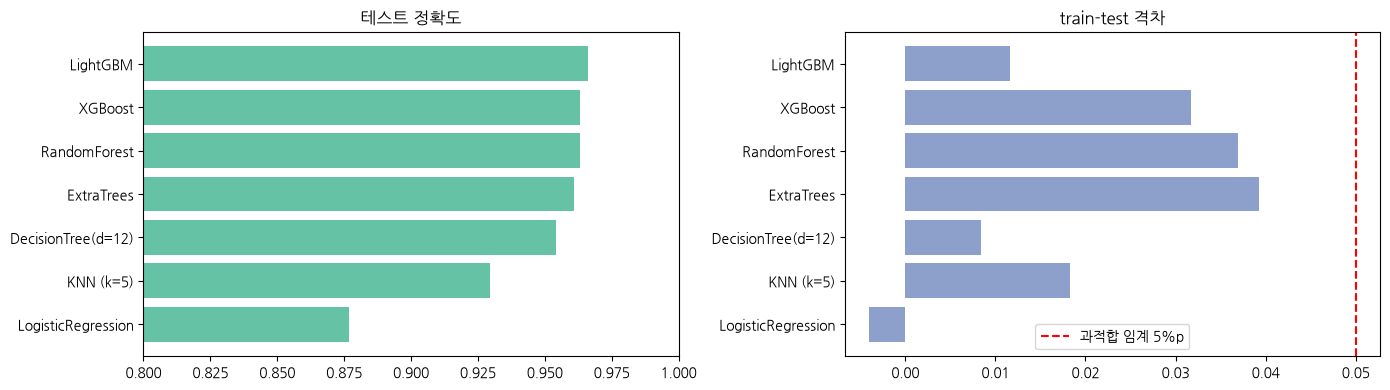

In [20]:
res_df = pd.DataFrame(results).drop(columns=['_model', '_proba', '_pred'])
res_df = res_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
display(res_df.style.format({
    'train정확도': '{:.4f}', 'test정확도': '{:.4f}', 'ROC_AUC': '{:.4f}',
    'F1_만족': '{:.4f}', 'precision_만족': '{:.4f}', 'recall_만족': '{:.4f}',
    '격차': '{:+.4f}', '시간초': '{:.1f}'
}).background_gradient(subset=['ROC_AUC'], cmap='Greens'))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
o = res_df.sort_values('test정확도')
ax[0].barh(o['모델'], o['test정확도'], color=sns.color_palette('Set2')[0])
ax[0].set_xlim(0.8, 1.0); ax[0].set_title('테스트 정확도')
ax[1].barh(o['모델'], o['격차'], color=sns.color_palette('Set2')[2])
ax[1].axvline(0.05, ls='--', c='red', label='과적합 임계 5%p')
ax[1].set_title('train-test 격차'); ax[1].legend()
plt.tight_layout(); plt.show()

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
top3 = res_df.head(3)['모델'].tolist()
print(f'교차검증 대상: {top3}\n')

cv_rows = []
for name in top3:
    t0 = time.time()
    sc = cross_val_score(MODELS[name], X_train_s, y_train,
                         cv=cv, scoring='roc_auc', n_jobs=1)
    cv_rows.append(dict(모델=name, CV평균AUC=sc.mean(), CV표준편차=sc.std(),
                        최소=sc.min(), 최대=sc.max(), 시간초=time.time()-t0))
    print(f'{name:22s} AUC {sc.mean():.4f} ± {sc.std():.4f}   ({time.time()-t0:.0f}s)')

cv_df = pd.DataFrame(cv_rows)
display(cv_df.style.format({'CV평균AUC': '{:.4f}', 'CV표준편차': '{:.4f}',
                            '최소': '{:.4f}', '최대': '{:.4f}', '시간초': '{:.0f}'}))

교차검증 대상: ['LightGBM', 'XGBoost', 'RandomForest']

LightGBM               AUC 0.9950 ± 0.0005   (6s)
XGBoost                AUC 0.9944 ± 0.0004   (4s)
RandomForest           AUC 0.9936 ± 0.0005   (7s)


,모델,CV평균AUC,CV표준편차,최소,최대,시간초
0,LightGBM,0.9950,0.0005,0.9943,0.9955,6
1,XGBoost,0.9944,0.0004,0.9939,0.9951,4
2,RandomForest,0.9936,0.0005,0.9929,0.9941,7


In [22]:
BEST = cv_df.sort_values('CV평균AUC', ascending=False).iloc[0]['모델']
print(f'튜닝 대상: {BEST}')

GRIDS = {
    'LightGBM': {
        'n_estimators': [200, 300, 400],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 63],
        'min_child_samples': [10, 20, 40],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
        'reg_lambda': [0, 1, 5],
    },
    'XGBoost': {
        'n_estimators': [200, 300, 400],
        'learning_rate': [0.05, 0.1],
        'max_depth': [5, 7, 9],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
    },
    'RandomForest': {
        'n_estimators': [200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
    'ExtraTrees': {
        'n_estimators': [200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
}

# 탐색은 서브샘플(3만 행)로 — 전체로 돌리면 1코어 환경에서 매우 오래 걸립니다.
# 하이퍼파라미터의 상대적 우열은 서브샘플에서도 대체로 보존됩니다.
SEARCH_N = min(30_000, len(X_train_s))
idx = np.random.RandomState(RS).choice(len(X_train_s), SEARCH_N, replace=False)

base = MODELS[BEST]
search = RandomizedSearchCV(
    base, GRIDS[BEST], n_iter=5, cv=3, scoring='roc_auc',
    random_state=RS, n_jobs=1, verbose=0
)
t0 = time.time()
search.fit(X_train_s[idx], y_train[idx])
print(f'탐색 완료 ({time.time()-t0:.0f}s, 서브샘플 {SEARCH_N:,}행)')
print('최적 파라미터:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'탐색 최고 CV AUC: {search.best_score_:.4f}')

# 찾은 파라미터로 전체 훈련 데이터에 다시 학습
best_model = search.best_estimator_.__class__(**{**search.best_estimator_.get_params()})
best_model.fit(X_train_s, y_train)
print(f'\n전체 훈련 데이터({len(X_train_s):,}행)로 재학습 완료')

튜닝 대상: LightGBM
탐색 완료 (19s, 서브샘플 30,000행)
최적 파라미터:
  subsample: 0.8
  reg_lambda: 5
  num_leaves: 63
  n_estimators: 400
  min_child_samples: 40
  learning_rate: 0.05
  colsample_bytree: 0.7
탐색 최고 CV AUC: 0.9941

전체 훈련 데이터(83,123행)로 재학습 완료


In [23]:
tuned = run_model(f'{BEST} (튜닝)', best_model, X_train_s, y_train, X_test_s, y_test)

before = res_df[res_df['모델'] == BEST].iloc[0]
print()
comp = pd.DataFrame({
    '': ['튜닝 전', '튜닝 후'],
    'train정확도': [before['train정확도'], tuned['train정확도']],
    'test정확도':  [before['test정확도'],  tuned['test정확도']],
    'ROC_AUC':     [before['ROC_AUC'],     tuned['ROC_AUC']],
    '격차':        [before['격차'],        tuned['격차']],
}).set_index('')
display(comp.style.format('{:.4f}'))

LightGBM (튜닝)          train 0.9765 | test 0.9662 | AUC 0.9957 | F1 0.9604 | 격차 +0.0103 (정상) | 2.7s



,train정확도,test정확도,ROC_AUC,격차
,,,,
튜닝 전,0.9779,0.9663,0.9956,0.0117
튜닝 후,0.9765,0.9662,0.9957,0.0103


              precision    recall  f1-score   support

   불만족/중립(0)     0.9606    0.9805    0.9705     11776
       만족(1)     0.9738    0.9475    0.9604      9005

    accuracy                         0.9662     20781
   macro avg     0.9672    0.9640    0.9654     20781
weighted avg     0.9663    0.9662    0.9661     20781



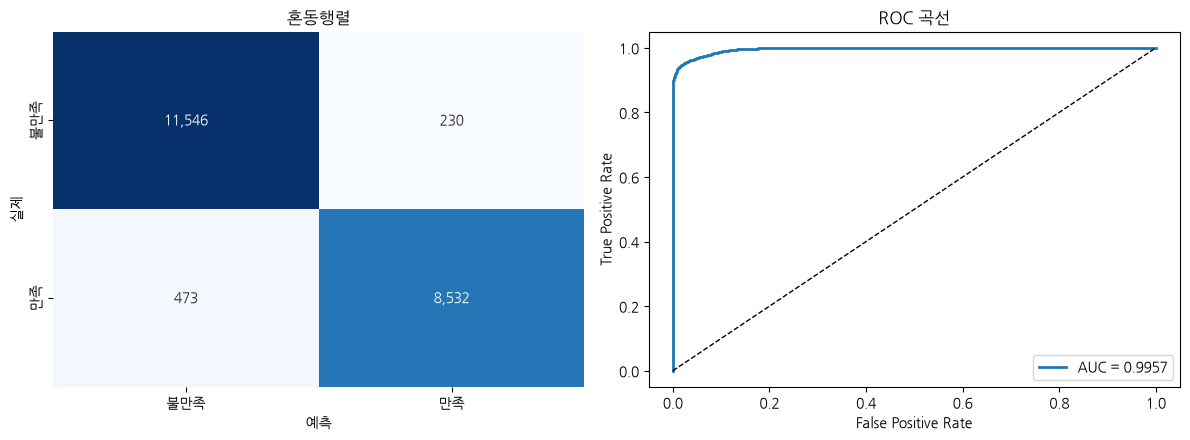

실제 만족인데 불만족으로 예측(FN): 473명
실제 불만족인데 만족으로 예측(FP): 230명


In [24]:
y_pred  = tuned['_pred']
y_proba = tuned['_proba']

print(classification_report(y_test, y_pred, digits=4,
                            target_names=['불만족/중립(0)', '만족(1)']))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['불만족', '만족'], yticklabels=['불만족', '만족'])
ax[0].set_xlabel('예측'); ax[0].set_ylabel('실제'); ax[0].set_title('혼동행렬')

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, lw=2, label=f'AUC = {tuned["ROC_AUC"]:.4f}')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC 곡선'); ax[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'실제 만족인데 불만족으로 예측(FN): {fn:,}명')
print(f'실제 불만족인데 만족으로 예측(FP): {fp:,}명')

In [25]:
# (1) 상관
corr_imp = rs.reindex(FEATURES).abs().rename('상관(절댓값)')

# (2) 트리 기반 importance
tree_imp = pd.Series(best_model.feature_importances_, index=FEATURES, name='importance')
tree_imp = tree_imp / tree_imp.sum()

imp_df = pd.concat([corr_imp, tree_imp], axis=1)
imp_df['상관_순위'] = imp_df['상관(절댓값)'].rank(ascending=False)
imp_df['importance_순위'] = imp_df['importance'].rank(ascending=False)
display(imp_df.sort_values('importance', ascending=False)
        .style.format({'상관(절댓값)': '{:.4f}', 'importance': '{:.4f}',
                       '상관_순위': '{:.0f}', 'importance_순위': '{:.0f}'}))

,상관(절댓값),importance,상관_순위,importance_순위
Flight_Distance,0.2967,0.1291,7,1
Age,0.1370,0.1173,14,2
Inflight_wifi_service,0.2867,0.0729,8,3
Departure_Delay_in_Minutes,0.0489,0.0677,15,4
Baggage_handling,0.2472,0.0549,9,5
Inflight_service,0.2446,0.0533,10,6
Gate_location,0.0006,0.0471,17,7
Seat_comfort,0.3474,0.0438,3,8
Inflight_entertainment,0.3959,0.0430,2,9
Checkin_service,0.2380,0.0415,11,10


c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
C:\Users\KDT11\AppData\Local\Temp\ipykernel_18796\4168995322.py:17: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()


SHAP 계산 3s   shape=(2000, 21)


C:\Users\KDT11\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


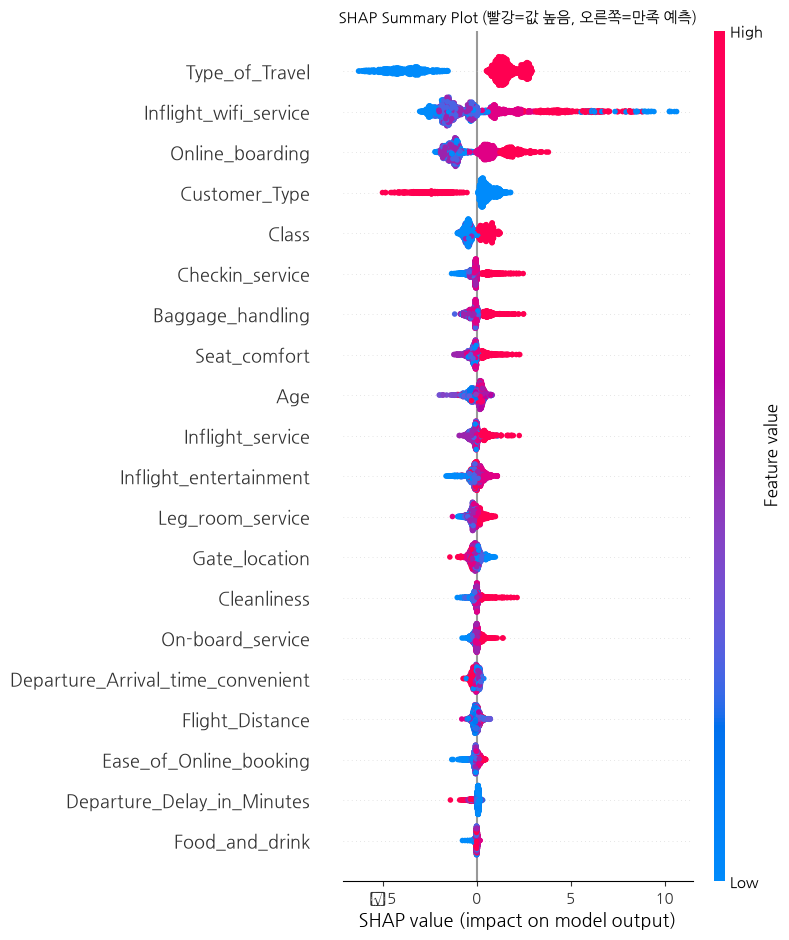

In [26]:
import shap

X_sample = X_test.sample(n=2000, random_state=RS)
X_sample_s = scaler.transform(X_sample)

t0 = time.time()
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample_s)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
print(f'SHAP 계산 {time.time()-t0:.0f}s   shape={shap_values.shape}')

shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Plot (빨강=값 높음, 오른쪽=만족 예측)', fontsize=11)
plt.tight_layout(); plt.show()

,상관순위,importance순위,SHAP순위,평균순위
Inflight_wifi_service,8.0,3.0,2.0,4.3
Online_boarding,1.0,14.0,3.0,6.0
Seat_comfort,3.0,8.0,8.0,6.3
Baggage_handling,9.0,5.0,7.0,7.0
Inflight_entertainment,2.0,9.0,11.0,7.3
Flight_Distance,7.0,1.0,17.0,8.3
Age,14.0,2.0,9.0,8.3
Inflight_service,10.0,6.0,10.0,8.7
Checkin_service,11.0,10.0,6.0,9.0
Leg_room_service,5.0,11.5,12.0,9.5


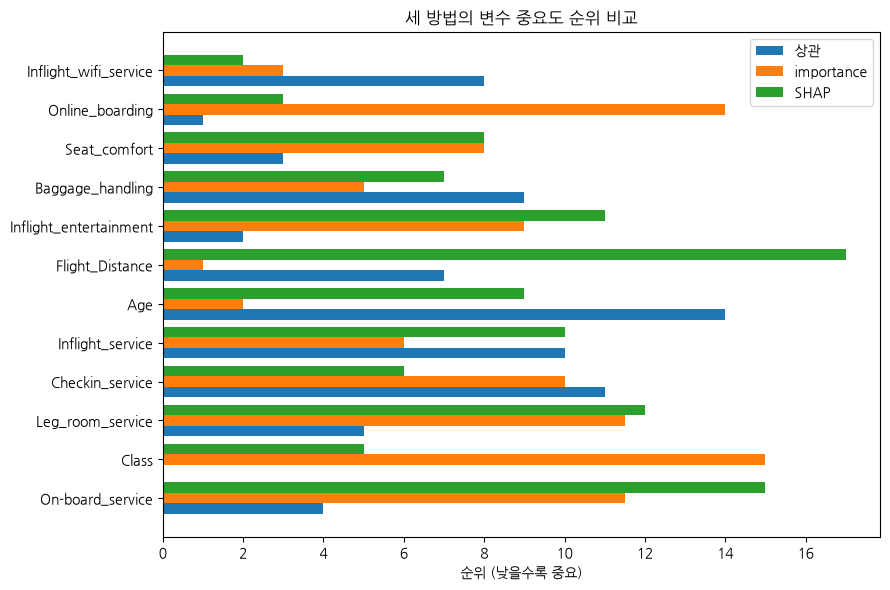

In [27]:
shap_imp = pd.Series(np.abs(shap_values).mean(0), index=FEATURES, name='SHAP')

final = pd.DataFrame({
    '상관순위':       corr_imp.rank(ascending=False),
    'importance순위': tree_imp.rank(ascending=False),
    'SHAP순위':       shap_imp.rank(ascending=False),
})
final['평균순위'] = final.mean(axis=1)
final = final.sort_values('평균순위')
display(final.style.format('{:.1f}').background_gradient(subset=['평균순위'], cmap='Greens_r'))

fig, ax = plt.subplots(figsize=(9, 6))
top = final.head(12).index[::-1]
w = 0.27
yp = np.arange(len(top))
for i, (c, lb) in enumerate([('상관순위', '상관'), ('importance순위', 'importance'), ('SHAP순위', 'SHAP')]):
    ax.barh(yp + (i-1)*w, final.loc[top, c], height=w, label=lb)
ax.set_yticks(yp); ax.set_yticklabels(top)
ax.set_xlabel('순위 (낮을수록 중요)'); ax.legend()
ax.set_title('세 방법의 변수 중요도 순위 비교')
plt.tight_layout(); plt.show()

In [28]:
top4 = final.head(4).index.tolist()
print(f'상위 4개 변수: {top4}\n')

for c in top4:
    g = train_df.groupby(c)[TARGET].agg(['mean', 'size'])
    g.columns = ['만족률', '건수']
    print(f'── {c} ──')
    print(g.to_string(float_format=lambda v: f'{v:.4f}'))
    print()

상위 4개 변수: ['Inflight_wifi_service', 'Online_boarding', 'Seat_comfort', 'Baggage_handling']

── Inflight_wifi_service ──
                         만족률     건수
Inflight_wifi_service              
0                     0.9971   2451
1                     0.3249  14281
2                     0.2481  20619
3                     0.2503  20743
4                     0.6014  15841
5                     0.9905   9188

── Online_boarding ──
                   만족률     건수
Online_boarding              
0               0.5556   1942
1               0.1361   8537
2               0.1163  14044
3               0.1367  17452
4               0.6231  24599
5               0.8721  16549

── Seat_comfort ──
                만족률     건수
Seat_comfort              
1            0.2235   9693
2            0.2258  11933
3            0.2143  15043
4            0.5628  25314
5            0.6476  21140

── Baggage_handling ──
                    만족률     건수
Baggage_handling              
1                0.2985   5722
2  

In [29]:
print('=' * 66)
print('  항공 승객 만족도 예측 — 최종 요약')
print('=' * 66)
print(f'  데이터        train {X_train.shape[0]:,} / test {X_test.shape[0]:,} · 피처 {len(FEATURES)}개')
print(f'  최종 모델     {BEST} (RandomizedSearchCV 튜닝)')
print(f'  테스트 정확도 {tuned["test정확도"]:.4f}')
print(f'  ROC-AUC       {tuned["ROC_AUC"]:.4f}')
print(f'  F1 (만족)     {tuned["F1_만족"]:.4f}')
print(f'  train-test 격차 {tuned["격차"]:+.4f} → {tuned["판정"]}')
print('-' * 66)
print('  핵심 변수 (3중 교차검증 평균순위 상위 5)')
for i, (n, r) in enumerate(final.head(5)['평균순위'].items(), 1):
    print(f'    {i}. {n:32s} (평균순위 {r:.1f})')
print('=' * 66)

  항공 승객 만족도 예측 — 최종 요약
  데이터        train 83,123 / test 20,781 · 피처 21개
  최종 모델     LightGBM (RandomizedSearchCV 튜닝)
  테스트 정확도 0.9662
  ROC-AUC       0.9957
  F1 (만족)     0.9604
  train-test 격차 +0.0103 → 정상
------------------------------------------------------------------
  핵심 변수 (3중 교차검증 평균순위 상위 5)
    1. Inflight_wifi_service            (평균순위 4.3)
    2. Online_boarding                  (평균순위 6.0)
    3. Seat_comfort                     (평균순위 6.3)
    4. Baggage_handling                 (평균순위 7.0)
    5. Inflight_entertainment           (평균순위 7.3)


In [30]:
import numpy as np

y_true      = np.asarray(y_test).ravel()
is_personal = (X_test['Type_of_Travel'] == 0).values

yp = y_true[is_personal]

print('yp 길이:', len(yp))          # 6456 이어야 정상
print('만족 고객 수:', yp.sum())     # 607 근처
print('만족률:', yp.mean().round(4)) # 0.0940

yp 길이: 6456
만족 고객 수: 607
만족률: 0.094


In [31]:
from sklearn.metrics import recall_score, f1_score
is_personal = (X_test['Type_of_Travel'] == 0).values
base_cols = [c for c in X_train.columns]
def evaluate(cols, label):
    m = LGBMClassifier(random_state=42, verbose=-1).fit(X_train[cols], y_train)
    pred = m.predict(X_test[cols])
    pp   = pred[is_personal]
    print(f'{label:12s} 전체 {m.score(X_test[cols], y_test):.4f} | '
          f'Personal 재현율 {recall_score(yp, pp, zero_division=0):.4f} | '
          f'F1 {f1_score(yp, pp, zero_division=0):.4f}')
    return m

m_base = evaluate(base_cols, '기준(22개)')

기준(22개)      전체 0.9644 | Personal 재현율 0.5997 | F1 0.7497


In [32]:
import numpy as np, pandas as pd

SVC = ['Inflight_wifi_service', 'Departure_Arrival_time_convenient',
       'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink',
       'Online_boarding', 'Seat_comfort', 'Inflight_entertainment',
       'On-board_service', 'Leg_room_service', 'Baggage_handling',
       'Checkin_service', 'Inflight_service', 'Cleanliness']

SVC = [c for c in SVC if c in base_cols]        # 존재 확인
print(f'{len(SVC)}개 항목:', SVC)

Xb = X_test[base_cols]                          # 상호작용 컬럼 제외
base_rate = m_base.predict_proba(Xb)[:, 1].mean()
print(f'현재 예측 만족률: {base_rate:.4f}')

14개 항목: ['Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness']
현재 예측 만족률: 0.4364


In [33]:
rows = []
for c in SVC:
    Xc = Xb.copy()
    used = Xc[c] >= 1                            # 0점(미이용)은 제외 — 아래 설명 참조
    Xc.loc[used, c] = np.minimum(Xc.loc[used, c] + 1, 5)

    new_rate = m_base.predict_proba(Xc)[:, 1].mean()
    rows.append({
        '항목'          : c,
        '현재_평균평점' : Xb.loc[used, c].mean(),
        '개선효과_%p'   : (new_rate - base_rate) * 100,
        '대상비율'      : used.mean(),
        '이미5점_비율'  : (Xb[c] == 5).mean(),
    })

sim = pd.DataFrame(rows).set_index('항목').sort_values('개선효과_%p', ascending=False)
sim['우선순위점수'] = sim['개선효과_%p'] / sim['현재_평균평점']
display(sim.round(3))

,현재_평균평점,개선효과_%p,대상비율,이미5점_비율,우선순위점수
항목,,,,,
Inflight_wifi_service,2.811,11.956,0.969,0.110,4.254
Online_boarding,3.331,4.150,0.977,0.200,1.246
Baggage_handling,3.626,3.157,1.000,0.260,0.871
Checkin_service,3.308,3.144,1.000,0.202,0.951
Inflight_service,3.640,2.825,1.000,0.262,0.776
Seat_comfort,3.452,2.597,1.000,0.256,0.752
Cleanliness,3.285,1.922,1.000,0.214,0.585
On-board_service,3.383,0.969,1.000,0.224,0.287
Leg_room_service,3.379,0.378,0.995,0.237,0.112


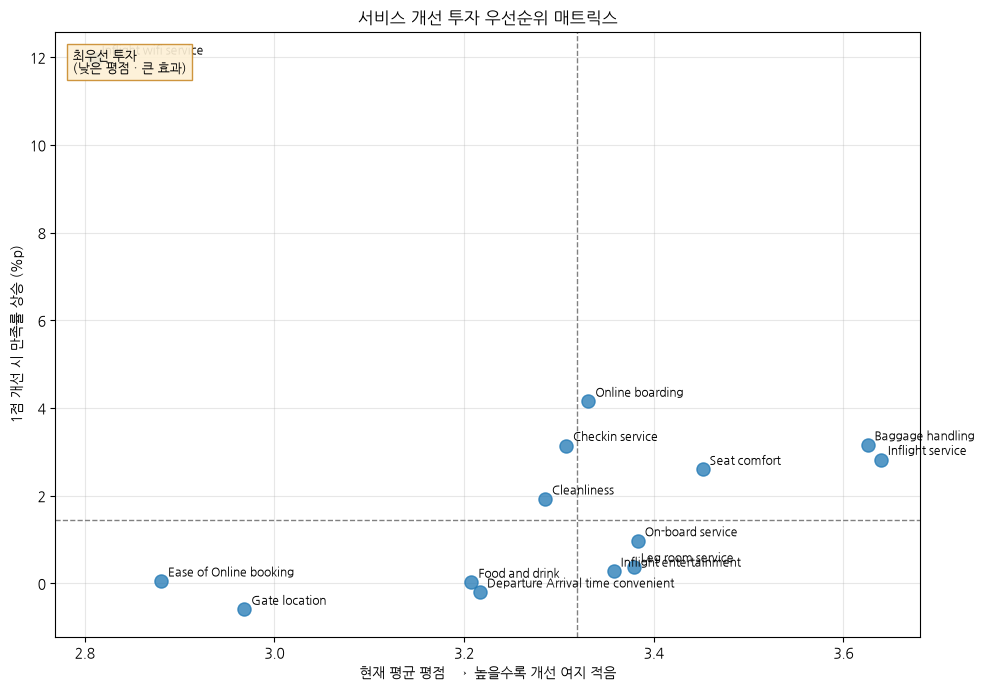

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(sim['현재_평균평점'], sim['개선효과_%p'], s=90, alpha=.75, zorder=3)

for name, r in sim.iterrows():
    ax.annotate(name.replace('_', ' '), (r['현재_평균평점'], r['개선효과_%p']),
                fontsize=8.5, xytext=(5, 4), textcoords='offset points')

ax.axvline(sim['현재_평균평점'].median(), color='gray', ls='--', lw=1)
ax.axhline(sim['개선효과_%p'].median(), color='gray', ls='--', lw=1)
ax.set_xlabel('현재 평균 평점  →  높을수록 개선 여지 적음')
ax.set_ylabel('1점 개선 시 만족률 상승 (%p)')
ax.set_title('서비스 개선 투자 우선순위 매트릭스')
ax.text(0.02, 0.97, '최우선 투자\n(낮은 평점 · 큰 효과)', transform=ax.transAxes,
        va='top', fontsize=9, bbox=dict(fc='#fdf0d5', ec='#c98a2b', alpha=.9))
ax.grid(alpha=.3, zorder=0)
plt.tight_layout()

In [35]:
seg_res = {}
for label, mask in [('Personal', Xb['Type_of_Travel'] == 0),
                    ('Business', Xb['Type_of_Travel'] == 1)]:
    Xs = Xb[mask.values]
    b = m_base.predict_proba(Xs)[:, 1].mean()
    eff = {}
    for c in SVC:
        Xc = Xs.copy()
        u = Xc[c] >= 1
        Xc.loc[u, c] = np.minimum(Xc.loc[u, c] + 1, 5)
        eff[c] = (m_base.predict_proba(Xc)[:, 1].mean() - b) * 100
    seg_res[label] = pd.Series(eff)

seg_df = pd.DataFrame(seg_res)
seg_df['격차'] = seg_df['Personal'] - seg_df['Business']
print(seg_df.sort_values('격차', ascending=False).round(3).to_string())

                                   Personal  Business      격차
Inflight_wifi_service                19.802     8.419  11.382
Gate_location                        -0.074    -0.829   0.755
Departure_Arrival_time_convenient    -0.144    -0.225   0.081
Ease_of_Online_booking                0.043     0.055  -0.012
Food_and_drink                       -0.015     0.040  -0.055
Inflight_entertainment                0.006     0.397  -0.391
Leg_room_service                      0.073     0.516  -0.442
On-board_service                     -0.006     1.409  -1.415
Cleanliness                           0.007     2.785  -2.778
Seat_comfort                          0.006     3.765  -3.760
Inflight_service                      0.062     4.070  -4.009
Checkin_service                       0.063     4.533  -4.470
Baggage_handling                      0.064     4.551  -4.487
Online_boarding                      -0.058     6.047  -6.105


In [36]:
from lightgbm import LGBMClassifier

# X_train도 배열이라면 DataFrame으로 복원
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=X_test.columns)
best_model = LGBMClassifier(random_state=42, verbose=-1).fit(X_train, y_train)

# 검증
print('피처 이름:', best_model.feature_name_[:3], '...')   # 실제 컬럼명이 나와야 함
print('정확도  :', round(best_model.score(X_test, y_test), 4))   # 0.966 근처

top6 = sim.sort_values('개선효과_%p', ascending=False).head(6).index.to_list() + ['Type_of_Travel', 'Class']
slim = LGBMClassifier().fit(X_train[top6], y_train)
print('전체 22개 변수:', best_model.score(X_test, y_test))
print('핵심 8개 변수 :', slim.score(X_test[top6], y_test))

피처 이름: ['Gender', 'Customer_Type', 'Age'] ...
정확도  : 0.9644
전체 22개 변수: 0.9644386699388865
핵심 8개 변수 : 0.9417737356238872


k=2  실루엣 0.1816  CH 19,785  DB 1.9842  최소군집 0.444
k=3  실루엣 0.1466  CH 15,892  DB 1.9970  최소군집 0.302
k=4  실루엣 0.1452  CH 14,371  DB 1.9279  최소군집 0.234
k=5  실루엣 0.1371  CH 12,304  DB 2.0051  최소군집 0.140
k=6  실루엣 0.1334  CH 11,100  DB 2.0389  최소군집 0.126
k=7  실루엣 0.1276  CH 10,261  DB 2.0274  최소군집 0.122
k=8  실루엣 0.1268  CH 9,485  DB 1.9861  최소군집 0.102
선택된 군집 수 K = 4

실루엣 계수      0.1452
Calinski-Harabasz 14,371
Davies-Bouldin   1.9279
→ 판정: 군집 구조가 약함 — 해석에 주의 필요


,건수,비율
cluster,,
0,19808,0.2383
1,20033,0.2410
2,23870,0.2872
3,19412,0.2335


,실루엣평균,표준편차,표본수
cluster,,,
0,0.1296,0.0928,2381
1,0.0880,0.0815,2428
2,0.2067,0.1072,2827
3,0.1463,0.0960,2364


C:\Users\KDT11\AppData\Local\Temp\ipykernel_18796\1320970935.py:77: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\KDT11\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


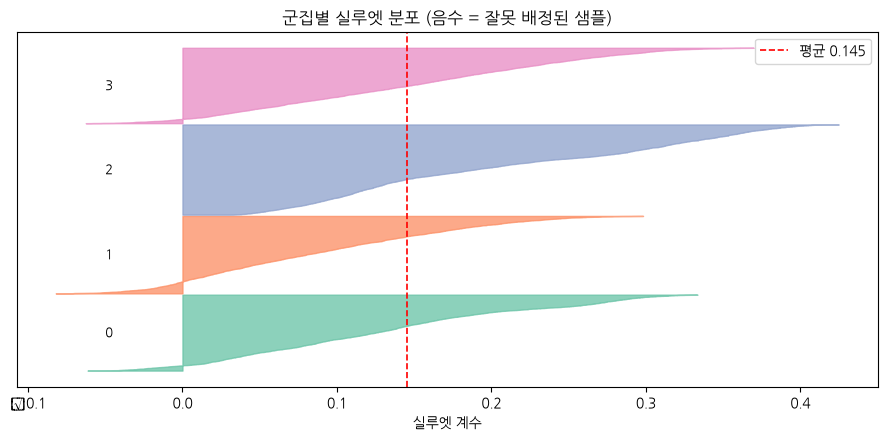

In [37]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)
clu_df = train_df.copy()
ks = range(2, 9)
rows = []
clu_scaler = StandardScaler()

CLUSTER_COLS = list(rating_cols)
X_clu = clu_scaler.fit_transform(clu_df[CLUSTER_COLS])
rng = np.random.RandomState(RS)
sil_idx = rng.choice(len(X_clu), size=min(10000, len(X_clu)), replace=False)
for k in ks:
    km  = KMeans(n_clusters=k, random_state=RS, n_init=10)
    lab = km.fit_predict(X_clu)
    rows.append({
        'k'      : k,
        'inertia': km.inertia_,
        '실루엣' : silhouette_score(X_clu[sil_idx], lab[sil_idx]),
        'CH'     : calinski_harabasz_score(X_clu, lab),
        'DB'     : davies_bouldin_score(X_clu, lab),
        '최소군집비율': np.bincount(lab).min() / len(lab),
    })
    print(f"k={k}  실루엣 {rows[-1]['실루엣']:.4f}  "
          f"CH {rows[-1]['CH']:,.0f}  DB {rows[-1]['DB']:.4f}  "
          f"최소군집 {rows[-1]['최소군집비율']:.3f}")

k_df = pd.DataFrame(rows).set_index('k')
# ── 9-2. 최종 군집 학습 및 품질 판정 ──────────────────────
# K = int(k_df['실루엣'].idxmax())          # 필요하면 수동 지정: K = 4
K=4
print(f'선택된 군집 수 K = {K}\n')

kmeans = KMeans(n_clusters=K, random_state=RS, n_init=10)
labels = kmeans.fit_predict(X_clu)
clu_df['cluster'] = labels

sil_avg = silhouette_score(X_clu[sil_idx], labels[sil_idx])
ch_val  = calinski_harabasz_score(X_clu, labels)
db_val  = davies_bouldin_score(X_clu, labels)

print(f'실루엣 계수      {sil_avg:.4f}')
print(f'Calinski-Harabasz {ch_val:,.0f}')
print(f'Davies-Bouldin   {db_val:.4f}')

# 판정 기준 (실루엣)
if   sil_avg >= 0.50: verdict = '군집이 뚜렷하게 분리됨'
elif sil_avg >= 0.25: verdict = '어느 정도 구조는 있으나 경계가 흐림'
else:                 verdict = '군집 구조가 약함 — 해석에 주의 필요'
print(f'→ 판정: {verdict}')

size = pd.Series(np.bincount(labels), name='건수').to_frame()
size['비율'] = (size['건수'] / size['건수'].sum()).round(4)
size.index.name = 'cluster'
display(size)

# 군집별 실루엣 분포 — 특정 군집만 나쁜지 확인
sil_s = silhouette_samples(X_clu[sil_idx], labels[sil_idx])
per_clu = pd.Series(sil_s).groupby(labels[sil_idx]).agg(['mean', 'std', 'size'])
per_clu.columns = ['실루엣평균', '표준편차', '표본수']
per_clu.index.name = 'cluster'
display(per_clu.style.format({'실루엣평균': '{:.4f}', '표준편차': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(9, 4.5))
y_low = 0
for c in range(K):
    v = np.sort(sil_s[labels[sil_idx] == c])
    ax.fill_betweenx(np.arange(y_low, y_low + len(v)), 0, v, alpha=.75,
                     color=sns.color_palette('Set2')[c % 8])
    ax.text(-0.05, y_low + len(v) / 2, str(c), va='center', fontsize=9)
    y_low += len(v) + 40
ax.axvline(sil_avg, color='red', ls='--', lw=1.2, label=f'평균 {sil_avg:.3f}')
ax.set_xlabel('실루엣 계수'); ax.set_yticks([])
ax.set_title('군집별 실루엣 분포 (음수 = 잘못 배정된 샘플)')
ax.legend(); plt.tight_layout(); plt.show()

c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.draw()
C:\Users\KDT11\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


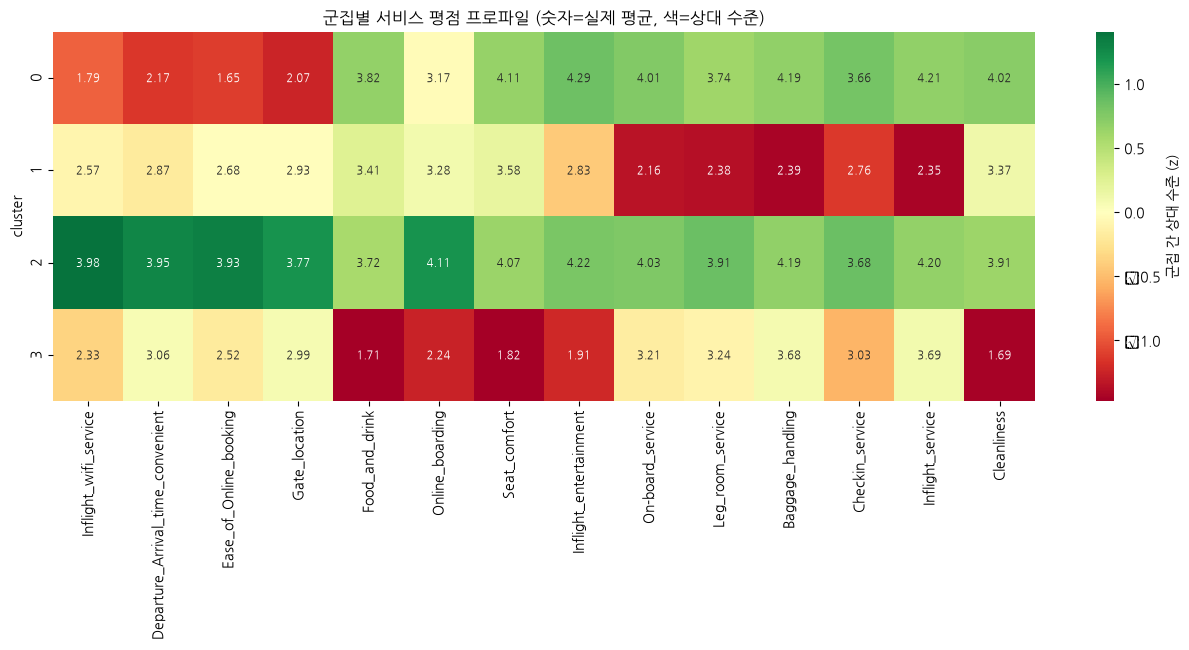

,건수,비율,만족률,비즈니스여행비율,충성고객비율,평균좌석등급,평균연령,평균비행거리,평균지연분
cluster,,,,,,,,,
0,"19,808",0.238,0.5513,0.717,0.835,1.23,40.0,"1,292",13.2
1,"20,033",0.241,0.2277,0.661,0.843,0.84,41.9,"1,116",15.8
2,"23,870",0.287,0.7351,0.789,0.873,1.33,41.2,"1,378",13.7
3,"19,412",0.234,0.1541,0.569,0.703,0.64,34.0,918,17.1



전체 만족률 0.4333
군집별 만족률 범위 0.1541 ~ 0.7351 (격차 0.5810)


In [39]:
# ── 9-4. 군집 프로파일링 ──────────────────────────────────
#  각 군집이 어떤 승객인지 — 평점 패턴 + 인구통계 + 만족률
# ------------------------------------------------------------
prof = clu_df.groupby('cluster')[CLUSTER_COLS].mean()

# z-score로 변환해야 '이 군집의 상대적 강점/약점'이 보인다
zprof = (prof - prof.mean()) / prof.std()

fig, ax = plt.subplots(figsize=(13, 1.1 * K + 2.2))
sns.heatmap(zprof, annot=prof.round(2), fmt='.2f', cmap='RdYlGn', center=0,
            annot_kws={'size': 8}, cbar_kws={'label': '군집 간 상대 수준 (z)'})
ax.set_title('군집별 서비스 평점 프로파일 (숫자=실제 평균, 색=상대 수준)', fontsize=12)
ax.set_xlabel(''); ax.set_ylabel('cluster')
plt.tight_layout(); plt.show()

summary = clu_df.groupby('cluster').agg(
    건수            =(TARGET, 'size'),
    만족률          =(TARGET, 'mean'),
    평균연령        =('Age', 'mean'),
    평균비행거리    =('Flight_Distance', 'mean'),
    비즈니스여행비율=('Type_of_Travel', 'mean'),
    충성고객비율    =('Customer_Type', lambda s: (s == 0).mean()),
    평균좌석등급    =('Class', 'mean'),
    평균지연분      =('Departure_Delay_in_Minutes', 'mean'),
)
summary['비율'] = summary['건수'] / summary['건수'].sum()
summary = summary[['건수', '비율', '만족률', '비즈니스여행비율', '충성고객비율',
                   '평균좌석등급', '평균연령', '평균비행거리', '평균지연분']]

display(summary.style.format({
    '건수': '{:,}', '비율': '{:.3f}', '만족률': '{:.4f}',
    '비즈니스여행비율': '{:.3f}', '충성고객비율': '{:.3f}',
    '평균좌석등급': '{:.2f}', '평균연령': '{:.1f}',
    '평균비행거리': '{:,.0f}', '평균지연분': '{:.1f}',
}).background_gradient(subset=['만족률'], cmap='RdYlGn'))

print(f'\n전체 만족률 {clu_df[TARGET].mean():.4f}')
print(f'군집별 만족률 범위 {summary["만족률"].min():.4f} ~ {summary["만족률"].max():.4f} '
      f'(격차 {summary["만족률"].max() - summary["만족률"].min():.4f})')

In [40]:
weak = pd.DataFrame({c: zprof.loc[c].nsmallest(4).index.tolist() for c in range(K)},
                    index=['1순위', '2순위', '3순위', '4순위']).T
weak.index.name = 'cluster'
display(weak)

print('\n실제 평점:')
display(prof.round(2).style.background_gradient(cmap='RdYlGn', axis=1))

,1순위,2순위,3순위,4순위
cluster,,,,
0,Gate_location,Departure_Arrival_time_convenient,Ease_of_Online_booking,Inflight_wifi_service
1,Inflight_service,Baggage_handling,Leg_room_service,On-board_service
2,Food_and_drink,Cleanliness,Seat_comfort,Inflight_service
3,Food_and_drink,Seat_comfort,Cleanliness,Online_boarding



실제 평점:


,Inflight_wifi_service,Departure_Arrival_time_convenient,Ease_of_Online_booking,Gate_location,Food_and_drink,Online_boarding,Seat_comfort,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness
cluster,,,,,,,,,,,,,,
0,1.790000,2.170000,1.650000,2.070000,3.820000,3.170000,4.110000,4.290000,4.010000,3.740000,4.190000,3.660000,4.210000,4.020000
1,2.570000,2.870000,2.680000,2.930000,3.410000,3.280000,3.580000,2.830000,2.160000,2.380000,2.390000,2.760000,2.350000,3.370000
2,3.980000,3.950000,3.930000,3.770000,3.720000,4.110000,4.070000,4.220000,4.030000,3.910000,4.190000,3.680000,4.200000,3.910000
3,2.330000,3.060000,2.520000,2.990000,1.710000,2.240000,1.820000,1.910000,3.210000,3.240000,3.680000,3.030000,3.690000,1.690000


In [43]:
test_labels = kmeans.predict(clu_scaler.transform(test_df[CLUSTER_COLS]))

seg_eff = {}
for c in range(K):
    m = test_labels == c
    Xs = X_test[m]
    b = m_base.predict_proba(Xs)[:, 1].mean()
    eff = {}
    for col in SVC:
        Xc = Xs.copy()
        u = Xc[col] >= 1
        Xc.loc[u, col] = np.minimum(Xc.loc[u, col] + 1, 5)
        eff[col] = (m_base.predict_proba(Xc)[:, 1].mean() - b) * 100
    seg_eff[f'군집{c}'] = pd.Series(eff)

eff_df = pd.DataFrame(seg_eff)
display(eff_df.round(2).style.background_gradient(cmap='Greens', axis=0))

print('\n군집별 1순위 개선 항목')
for c in eff_df.columns:
    print(f'  {c}: {eff_df[c].idxmax()}  (+{eff_df[c].max():.2f}%p)')

,군집0,군집1,군집2,군집3
Inflight_wifi_service,4.300000,15.020000,14.030000,14.250000
Departure_Arrival_time_convenient,-0.010000,-0.040000,-0.490000,-0.210000
Ease_of_Online_booking,0.070000,0.100000,-0.020000,0.060000
Gate_location,-0.530000,-0.620000,-0.750000,-0.450000
Food_and_drink,0.020000,0.090000,0.030000,-0.050000
Online_boarding,1.640000,11.210000,2.370000,1.620000
Seat_comfort,0.990000,7.160000,1.840000,0.460000
Inflight_entertainment,0.060000,1.060000,-0.370000,0.480000
On-board_service,0.620000,0.820000,1.150000,1.270000
Leg_room_service,0.210000,0.580000,0.420000,0.300000



군집별 1순위 개선 항목
  군집0: Inflight_wifi_service  (+4.30%p)
  군집1: Inflight_wifi_service  (+15.02%p)
  군집2: Inflight_wifi_service  (+14.03%p)
  군집3: Inflight_wifi_service  (+14.25%p)
